# Загружаю бибилиотеки

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Настройка кириллицы для графиков
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans', 'Tahoma']
sns.set(style="whitegrid")

# Загружаю датасет

In [101]:
df = pd.read_csv(r'F:\VSCODE_PROJECT\VVEDENEI_ML\LAB_2\final_depression_dataset_1.csv')
df.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,Ghaziabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,Kalyan,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,Bhopal,Working Professional,Teacher,NaN,2.0,NaN,NaN,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,Thane,Working Professional,Teacher,NaN,3.0,NaN,NaN,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,Indore,Working Professional,UX/UI Designer,NaN,4.0,NaN,NaN,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No


# 1.Обработка датасета

Удаляю дубликаты и фичи

In [102]:
df = df.drop_duplicates()
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

Избавляюсь от пропусков значений

In [103]:
df.isnull().sum()

Gender                                      0
Age                                         0
City                                        0
Working Professional or Student             0
Profession                                673
Academic Pressure                        2054
Work Pressure                             502
CGPA                                     2054
Study Satisfaction                       2054
Job Satisfaction                          502
Sleep Duration                              0
Dietary Habits                              0
Degree                                      0
Have you ever had suicidal thoughts ?       0
Work/Study Hours                            0
Financial Stress                            0
Family History of Mental Illness            0
Depression                                  0
dtype: int64

In [104]:
df['is_student'] = df['Working Professional or Student'].apply(lambda x: 1 if x == 'Student' else 0)

# Обнуляем нерелевантные параметры (у студентов нет работы, у профи нет учебы)
df.loc[df['is_student'] == 1, ['Work Pressure', 'Job Satisfaction']] = 0
df.loc[df['is_student'] == 0, ['Academic Pressure', 'Study Satisfaction']] = 0

In [105]:
df.isnull().sum()

Gender                                      0
Age                                         0
City                                        0
Working Professional or Student             0
Profession                                673
Academic Pressure                           0
Work Pressure                               0
CGPA                                     2054
Study Satisfaction                          0
Job Satisfaction                            0
Sleep Duration                              0
Dietary Habits                              0
Degree                                      0
Have you ever had suicidal thoughts ?       0
Work/Study Hours                            0
Financial Stress                            0
Family History of Mental Illness            0
Depression                                  0
is_student                                  0
dtype: int64

Избавляюсь от пропусков значений в CGPA

In [106]:
if 'CGPA' in df.columns and 'Degree' in df.columns:
    df['CGPA'] = df['CGPA'].fillna(df.groupby('Degree')['CGPA'].transform('median'))

In [107]:
df.isnull().sum()

Gender                                     0
Age                                        0
City                                       0
Working Professional or Student            0
Profession                               673
Academic Pressure                          0
Work Pressure                              0
CGPA                                       0
Study Satisfaction                         0
Job Satisfaction                           0
Sleep Duration                             0
Dietary Habits                             0
Degree                                     0
Have you ever had suicidal thoughts ?      0
Work/Study Hours                           0
Financial Stress                           0
Family History of Mental Illness           0
Depression                                 0
is_student                                 0
dtype: int64

Избавитсья от пропусков в профессии 

In [108]:
df['Working Professional or Student'] = df['Working Professional or Student'].fillna(df['Working Professional or Student'].mode()[0])

# Если человек — студент, то в поле Profession записываем 'Student'
df.loc[df['Working Professional or Student'] == 'Student', 'Profession'] = 'Student'

# Для работающих заполняем оставшиеся пустоты самым частым значением среди рабочих
df['Profession'] = df['Profession'].replace(['', ' ', 'None', 'NaN'], np.nan)

# Находим самую частую профессию  среди работающих
rabochaya_moda = df[df['Working Professional or Student'] == 'Working Professional']['Profession'].mode()[0]
df['Profession'] = df['Profession'].fillna(rabochaya_moda)

In [109]:
df.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
is_student                               0
dtype: int64

In [110]:
df.head()

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,is_student
0,Female,37,Ghaziabad,Working Professional,Teacher,0.0,2.0,9.27,0.0,4.0,7-8 hours,Moderate,MA,No,6,2,No,No,0
1,Male,60,Kalyan,Working Professional,Financial Analyst,0.0,4.0,6.78,0.0,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No,0
2,Female,42,Bhopal,Working Professional,Teacher,0.0,2.0,7.85,0.0,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No,0
3,Female,44,Thane,Working Professional,Teacher,0.0,3.0,7.35,0.0,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No,0
4,Male,48,Indore,Working Professional,UX/UI Designer,0.0,4.0,7.92,0.0,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No,0


Создание новых признаков и кодирование

In [111]:
sleep_map = {'Less than 5 hours': 4, '5-6 hours': 5.5, '7-8 hours': 7.5, 'More than 8 hours': 9}
df['Sleep_Numeric'] = df['Sleep Duration'].map(sleep_map)
# Индекс усталости
df['Fatigue_Index'] = df['Work/Study Hours'] / (df['Sleep_Numeric'] + 1)

kodirovshik = LabelEncoder()
for stolbec in df.columns:
    if not pd.api.types.is_numeric_dtype(df[stolbec]):
        df[stolbec] = kodirovshik.fit_transform(df[stolbec].astype(str))

df.head()

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,...,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,is_student,Sleep_Numeric,Fatigue_Index
0,0,37,7,1,33,0.0,2.0,9.27,0.0,4.0,...,1,18,0,6,2,0,0,0,7.5,0.705882
1,1,60,11,1,16,0.0,4.0,6.78,0.0,3.0,...,2,1,1,0,4,1,0,0,5.5,0.000000
2,0,42,3,1,33,0.0,2.0,7.85,0.0,3.0,...,1,14,0,0,2,0,0,0,5.5,0.000000
3,0,44,25,1,33,0.0,3.0,7.35,0.0,5.0,...,0,22,1,1,2,1,0,0,7.5,0.117647
4,1,48,9,1,35,0.0,4.0,7.92,0.0,3.0,...,1,8,1,6,5,1,0,0,7.5,0.705882


# 2,3.Разделение данных на тестовые и тренировочные и обучение модели

In [112]:
# Отделение целевой переменной
celevaya = 'Depression' if 'Depression' in df.columns else 'Depressed'
X = df.drop(columns=[celevaya])
y = df[celevaya]

X_obuchenie, X_test, y_obuchenie, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_lesa = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model_lesa.fit(X_obuchenie, y_obuchenie)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

# 4.Оценка качества

Числовые метрики

In [113]:
prognoz = model_lesa.predict(X_test)

print(f"Общая точность (Accuracy): {accuracy_score(y_test, prognoz):.4f}")
print("\nДетальный отчет:\n", classification_report(y_test, prognoz))

Общая точность (Accuracy): 0.9453

Детальный отчет:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       421
           1       0.92      0.76      0.83        91

    accuracy                           0.95       512
   macro avg       0.93      0.87      0.90       512
weighted avg       0.94      0.95      0.94       512



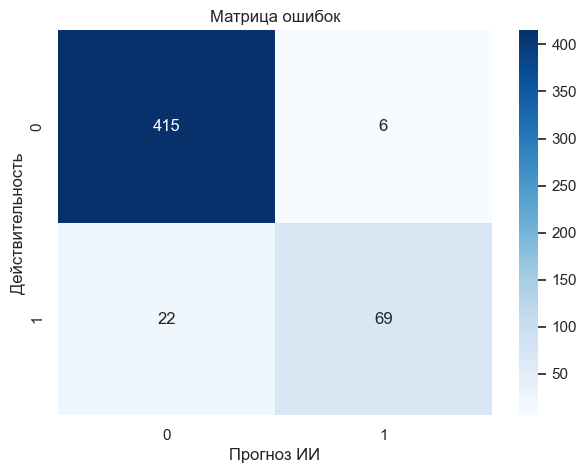

In [114]:
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, prognoz), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Прогноз ИИ')
plt.ylabel('Действительность')
plt.show()

Важность признаков

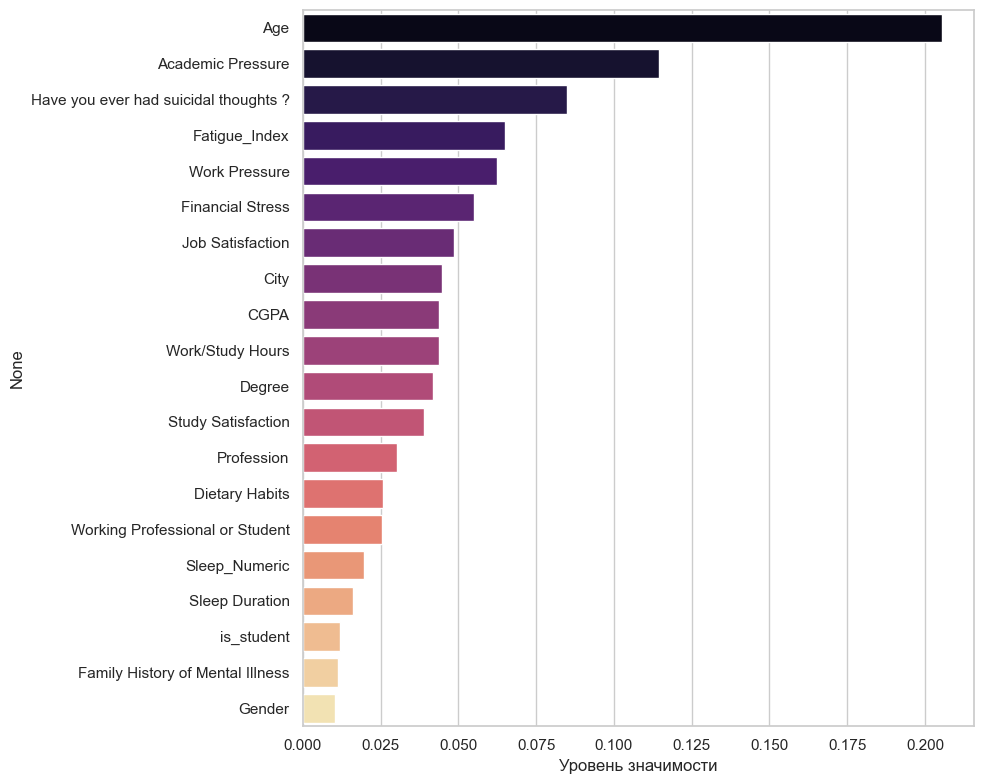

In [115]:
vazhnost = pd.Series(model_lesa.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=vazhnost, y=vazhnost.index, palette='magma', hue=vazhnost.index, legend=False)
plt.xlabel('Уровень значимости')
plt.tight_layout()
plt.show()